# Input

In [44]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import plots_dir, base_dir, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.utils.util import  retrieve_adata, retrieve_net,  get_consensus_net
from ciim.src.feature_association.helper import retrieve_feature_data
from ciim.src.clock.helper import clock_save_dir, predict_age
from ciim.src.clock.plots import plot_scatter_age_vs_predictedAge

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' 
tune_model = True
create_smoothed_data = True
only_targets = True
temp_dir = f'{save_dir}/temp/'
plt.rcParams["font.family"] = "Arial"
cell_types = ['CD4T', 'CD8T'] # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
train_datasets = aging_clock_train_datasets
n_cell_types = len(cell_types)
version = 'all_data'

def get_all_predictions(cell_types, evaluate_datasets, version='all_data'):
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs['condition'] = adata.obs['condition'].apply(lambda name: surrogate_names.get(name, name))
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type, version=version)
                obs = adata_c.obs
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    return obs

# Calculate feature space using consensus GRNs -> smoothed


In [84]:
datasets = ['ibd', 'parsebioscience', 'op'] + datasets_drug_perturbation + datasets_all + datasets_disease 
if False:
    adata_integrated = ad.read_h5ad(f'{save_dir}/gene_expression_smoothed/adata_latent_corrected.h5ad')
    for dataset in datasets:
        for cell_type in cell_types:
            print(f'Preparing data for {dataset} {cell_type} {feature_type}')
            adata = adata_integrated[(adata_integrated.obs['dataset'] == dataset)&(adata_integrated.obs['cell_type'] == cell_type)].copy()
            adata.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')
if True:
    from ciim.src.clock.helper import format_data
    for dataset in datasets:
    # for dataset in ['ibd']:
        for cell_type in cell_types:
            print(f'Preparing data for {dataset} {cell_type} {feature_type}')
            adata_s = format_data([dataset], cell_type=cell_type, data_type=data_type, only_ctr=False, only_targets=only_targets)
            # adata_s = adata[(adata.obs['dataset'] == dataset)&(adata.obs['cell_type'] == cell_type)].copy()
            obs = adata_s.obs.dropna(axis=1, how='all')
            adata_s.obs = obs
            for col in adata_s.obs.columns:
                if adata_s.obs[col].dtype == "object":
                    adata_s.obs[col] = adata_s.obs[col].astype(str)

            adata_s.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')

Preparing data for ibd CD4T gene_expression
Using layer lognorm
Datasets in merged adata: ['ibd']
Cell types in merged adata: ['CD4T']
Categories (1, object): ['CD4T']
Preparing data for ibd CD8T gene_expression
Using layer lognorm
Datasets in merged adata: ['ibd']
Cell types in merged adata: ['CD8T']
Categories (1, object): ['CD8T']
Preparing data for parsebioscience CD4T gene_expression
Using layer lognorm
Datasets in merged adata: ['parsebioscience']
Cell types in merged adata: ['CD4T']
Categories (1, object): ['CD4T']
Preparing data for parsebioscience CD8T gene_expression
Using layer lognorm
Datasets in merged adata: ['parsebioscience']
Cell types in merged adata: ['CD8T']
Categories (1, object): ['CD8T']
Preparing data for op CD4T gene_expression
Using layer X_norm
Datasets in merged adata: ['op']
Cell types in merged adata: ['CD4T']
Categories (1, object): ['CD4T']
Preparing data for op CD8T gene_expression
Using layer X_norm
Datasets in merged adata: ['op']
Cell types in merged

In [46]:
adata = ad.read_h5ad(f'{save_dir}/{feature_type}_smoothed/CXCL9_CD4T_{data_type}.h5ad')


# Train the model

In [47]:
if True:
    import subprocess
    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *train_datasets, # train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD4T CD8T --datasets_training data1 data7_allTPs_jalil SLE_European data13_Korean data13_Japanese data12 --feature_type gene_expression --data_type bulk --reg_type ridge --version all_data --temp_dir /vol/projects/jnourisa//output//temp/ --age_limit 20 --tune_model
{'cell_types': ['CD4T', 'CD8T'], 'datasets_training': ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Korean', 'data13_Japanese', 'data12'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'all_data', 'temp_dir': '/vol/projects/jnourisa//output//temp/', 'age_limit': 20}
building model for cell type: CD4T
dataset
data1                 976
data7_allTPs_jalil    313
data13_Korean         164
data13_Japanese       148
SLE_European           74
data12                 33
Name: count, dtype: int64


Best trial: 9. Best value: 0.567162: 100%|██████████| 30/30 [02:48<00:00,  5.61s/it]



 Best alpha: 708.6186, Best CV performance: 0.5672
building model for cell type: CD8T
dataset
data1                 976
data7_allTPs_jalil    313
data13_Korean         164
data13_Japanese       147
SLE_European           74
data12                 33
Name: count, dtype: int64


Best trial: 22. Best value: 0.405959: 100%|██████████| 30/30 [02:58<00:00,  5.96s/it]



 Best alpha: 858.6406, Best CV performance: 0.4060


# Cross-validation performance

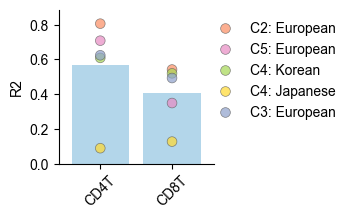

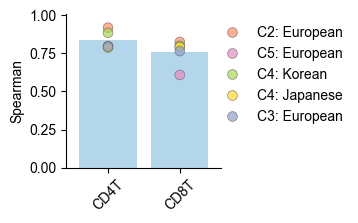

In [48]:
cv_scores_store = []
for cell_type in cell_types:
    scores_df = pd.read_csv(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_cv_scores.csv", 
                            index_col=0)
    mask = scores_df < 0
    scores_df[mask] = 0
    scores_df['cell_type'] = cell_type
    cv_scores_store.append(scores_df)
cv_scores = pd.concat(cv_scores_store, axis=0)
cv_scores.head()

# Ensure dataset name is a column
cv_scores = cv_scores.reset_index().rename(columns={'index': 'dataset'})

def plot_cv_scores(cv_scores, metric, figsize=[2.5, 2]):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Strip plot (scatter of individual fold scores)
    sns.stripplot(
        data=cv_scores, x='cell_type', y=metric,
        hue='dataset', dodge=False, jitter=False, s=7,
        alpha=0.7, linewidth=0.5, edgecolor='gray', palette=palette_datasets_pretty,
        ax=ax
    )

    # Bar plot (mean scores per cell type)
    sns.barplot(
        data=cv_scores, x='cell_type', y=metric,
        estimator='mean', errorbar=None,
        color=colors_blind[1], alpha=0.5, ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
    # Legend
    ax.legend(title='', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # Set axes properties
    ax.set(
        # title=f'{metric.upper()}',
        ylabel=metric.capitalize(),
        xlabel=''
    )
    return fig

figsize=(2, 2)
# Plot R² and Spearman
cv_scores = cv_scores[~cv_scores['dataset'].isin(['CXCL9', 'op'])]
cv_scores['dataset'] = cv_scores['dataset'].map(lambda name: surrogate_names.get(name, name))
fig = plot_cv_scores(cv_scores, 'r2', figsize)
fig.savefig(f'{plots_dir}/cv_scores_r2.png', bbox_inches='tight', dpi=300, transparent=True)
fig = plot_cv_scores(cv_scores, 'spearman',figsize)
fig.savefig(f'{plots_dir}/cv_scores_spearman.png', bbox_inches='tight', dpi=300, transparent=True)

In [49]:
# scatter plot
prediction_store = []
for cell_type in cell_types:
    predictions_df = pd.read_csv(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_cv_predictions.csv")
    predictions_df['cell_type'] = cell_type
    prediction_store.append(predictions_df)
prediction_df = pd.concat(prediction_store, axis=0)
prediction_df

,Unnamed: 0,age,predicted_age,dataset,fold,cell_type
0,0,30,33.297479,data7_allTPs_jalil,0,CD4T
1,1,31,35.630755,data7_allTPs_jalil,0,CD4T
2,2,27,45.026935,data7_allTPs_jalil,0,CD4T
3,3,29,45.486650,data7_allTPs_jalil,0,CD4T
4,4,33,40.256001,data7_allTPs_jalil,0,CD4T
...,...,...,...,...,...,...
726,28,22,43.963339,data12,4,CD8T
727,29,27,43.047091,data12,4,CD8T
728,30,26,41.211781,data12,4,CD8T
729,31,29,56.905618,data12,4,CD8T


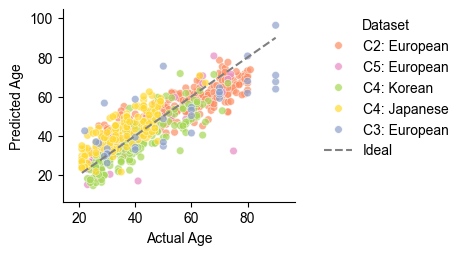

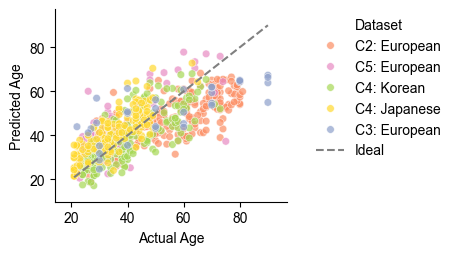

In [50]:
prediction_df['dataset'] = prediction_df['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in cell_types:
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharey=True)

    df = prediction_df[prediction_df['cell_type'] == cell_type]

    plot_scatter_age_vs_predictedAge(df, dataset='', ax=ax, hue='dataset', palette=palette_datasets_pretty, s=30, alpha=0.7)
    ax.legend(loc=(1.1, .2), frameon=False, title='Dataset')
    plt.savefig(f'{plots_dir}/clock_training_datasets.png', bbox_inches='tight', dpi=300, transparent=True)

#  Compare to wenchao's results

In [51]:
W_train_datasets = ['data1', 'data7_allTPs_jalil'] # we only use these datasets for training for a fair comparision
test_datasets = ['SLE_European', 'data13_Korean']

version = 'comparitive'

In [52]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *W_train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD4T CD8T --datasets_training data1 data7_allTPs_jalil --feature_type gene_expression --data_type bulk --reg_type ridge --version comparitive --temp_dir /vol/projects/jnourisa//output//temp/ --age_limit 20 --tune_model
{'cell_types': ['CD4T', 'CD8T'], 'datasets_training': ['data1', 'data7_allTPs_jalil'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'comparitive', 'temp_dir': '/vol/projects/jnourisa//output//temp/', 'age_limit': 20}
building model for cell type: CD4T
dataset
data1                 976
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 10. Best value: 0.675305: 100%|██████████| 30/30 [00:21<00:00,  1.40it/s]



 Best alpha: 985.4139, Best CV performance: 0.6753
building model for cell type: CD8T
dataset
data1                 976
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 11. Best value: 0.170526: 100%|██████████| 30/30 [00:21<00:00,  1.39it/s] 



 Best alpha: 969.5749, Best CV performance: 0.1705


## Get W results on test data

In [53]:
def extract_w_results():
    # - read the results of predictions
    df_store = []
    for dataset in ['C4', 'C5']:
        df = pd.read_csv(f'{clock_save_dir}/wenchao/val_data_majorCT_Wenchao_AC_{dataset}_predicted_age_donor.tsv', sep='\t')
        df['dataset'] = 'data13_Korean' if dataset=='C4' else 'SLE_European'
        df_store.append(df)
    df = pd.concat(df_store, axis=0)
    df['donor_age'] = df['donor_id'].astype(str) + '_' + df['age'].astype(str)
    # - format 
    df.rename(columns={'Prediction': 'predicted_age', 'CT': 'cell_type'}, inplace=True)
    df['sex'] = df['sex'].map({'M': 'Male', 'F': 'Female'})
    # - median prediction
    median_prediction = df.groupby(['cell_type', 'donor_age', 'dataset'])['predicted_age'].median().reset_index()
    median_prediction = df[['cell_type', 'donor_age', 'age', 'sex', 'dataset']].drop_duplicates().merge(median_prediction, on=['cell_type', 'donor_age', 'dataset'], how='left')
    return median_prediction
W_median_prediction = extract_w_results()

## Get our results on test data

In [54]:
predictions_all = get_all_predictions(cell_types, test_datasets, version=version)
predictions_all.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,batch_info
148,_CD4T_1004_39.0,Female,CD4T,SLE,SLE_European,CD4T,100439,39,1004,SLE,European,1469,False,54.443299,NaN
149,_CD4T_1014_40.0,Female,CD4T,SLE,SLE_European,CD4T,101440,40,1014,SLE,European,988,False,47.049866,NaN
150,_CD4T_1015_54.0,Female,CD4T,SLE,SLE_European,CD4T,101554,54,1015,SLE,European,971,False,61.984327,NaN
151,_CD4T_1019_64.0,Female,CD4T,SLE,SLE_European,CD4T,101964,64,1019,SLE,European,2014,False,64.918339,NaN
152,_CD4T_1039_42.0,Female,CD4T,SLE,SLE_European,CD4T,103942,42,1039,SLE,European,840,False,38.808730,NaN


In [55]:
from ciim.src.clock.helper import evaluate_groupwise_median
test_predictions = predictions_all[(predictions_all['dataset'].isin(test_datasets)) & (predictions_all['condition']=='Healthy')]
test_predictions.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,batch_info
224,_CD4T_HC-002_27.0,Male,CD4T,Healthy,SLE_European,CD4T,HC-00227,27,HC-002,SLE,European,1532,True,33.100073,NaN
225,_CD4T_HC-006_53.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00653,53,HC-006,SLE,European,2134,True,50.208439,NaN
226,_CD4T_HC-008_48.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00848,48,HC-008,SLE,European,792,True,50.249030,NaN
227,_CD4T_HC-009_27.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00927,27,HC-009,SLE,European,5346,True,24.595788,NaN
228,_CD4T_HC-020_35.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-02035,35,HC-020,SLE,European,1155,True,39.295195,NaN


In [56]:
test_predictions['dataset'].unique()

array(['SLE_European', 'data13_Korean'], dtype=object)

## Calculate the scores

In [57]:
import pandas as pd

all_scores = []

for cell_type in test_predictions['cell_type'].unique():
    for dataset in test_datasets:
        # Your model
        df1 = test_predictions[
            (test_predictions['dataset'] == dataset) & 
            (test_predictions['cell_type'] == cell_type)
        ].copy()
        ss1 = evaluate_groupwise_median(df1)  # returns {'Spearman': ..., 'R2': ...}
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'GRNdrived',
            'Spearman': ss1['Spearman'],
            'R2': ss1['R2']
        })

        # Wenchao's model
        df2 = W_median_prediction[
            (W_median_prediction['dataset'] == dataset) & 
            (W_median_prediction['cell_type'] == cell_type)
        ].copy()
        ss2 = evaluate_groupwise_median(df2)
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'Wenchao',
            'Spearman': ss2['Spearman'],
            'R2': ss2['R2']
        })

# Convert to DataFrame
score_df = pd.DataFrame(all_scores)


## Plot

In [58]:
palette_models = {
    'Wenchao': colors_blind[1], 
    'GRNdrived': colors_blind[0]
}

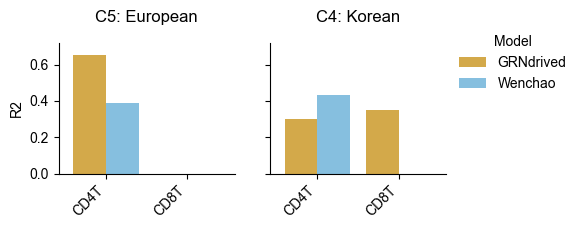

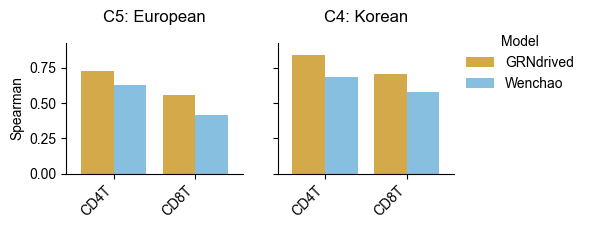

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clip R2 to [0, 1]
score_df['R2'] = score_df['R2'].clip(0, 1)

# Sort datasets for consistent layout
datasets = score_df['dataset'].unique()
n_datasets = len(datasets)

# Plot each metric in a separate figure
for metric in ['R2', 'Spearman']:
    fig, axes = plt.subplots(1, n_datasets, figsize=(2.5 * n_datasets, 1.7), sharey=True)

    if n_datasets == 1:
        axes = [axes]  # Ensure iterable if only one axis

    for ax, dataset in zip(axes, datasets):
        df_plot = score_df[score_df['dataset'] == dataset]

        sns.barplot(
            data=df_plot,
            x='cell_type',
            y=metric,
            hue='model',
            ax=ax,
            alpha=0.8,
            palette=palette_models,
        )   

        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.margins(x=0.1, y=0.1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.get_legend().remove()
        ax.set_title(f'{surrogate_names[dataset]}', pad=15)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Model', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # fig.tight_layout()
    plt.savefig(f'{plots_dir}/clock_comparison_{metric}.png', bbox_inches='tight', dpi=300, transparent=True)


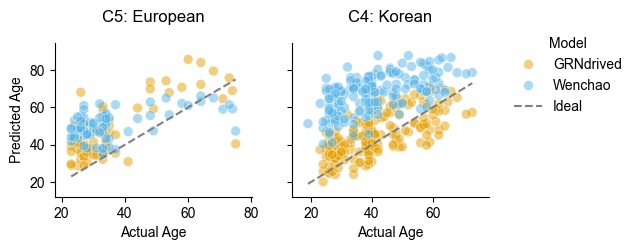

In [60]:
W_median_prediction['model'] = 'Wenchao'
test_predictions['model'] = 'GRNdrived'

obs = pd.concat([test_predictions, W_median_prediction], axis=0)
datasets = obs['dataset'].unique()

for cell_type in ['CD8T']:
    fig, axes = plt.subplots(1, len(datasets), figsize=(2.8*len(datasets), 2), sharey=True)
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

        plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax, hue='model', palette=palette_models)
        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .5), frameon=False, title='Model')
    plt.savefig(f'{plots_dir}/clock_comparison_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)
    
    # plt.suptitle(cell_type, fontsize=12, weight='bold')
    # plt.tight_layout()

# Performance on disease

In [61]:
obs = get_all_predictions(cell_types, ['SLE_European'])

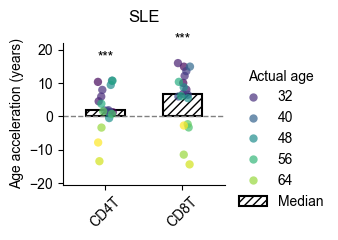

In [62]:
from ciim.src.clock.plots import wrapper_age_acceleration_disease, wrapper_age_acceleration_disease

# Call the function
wrapper_age_acceleration_disease(obs[obs['cell_type'].isin(['CD8T', 'CD4T'])], disease_dataset='SLE_European', figsize=(3.5, 2.5))
plt.savefig(f'{plots_dir}/clock_SLE.png', bbox_inches='tight', dpi=300, transparent=True)
# wrapper_age_acceleration_disease(obs, disease_dataset='Covid_50MHH')

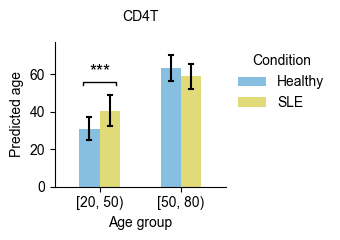

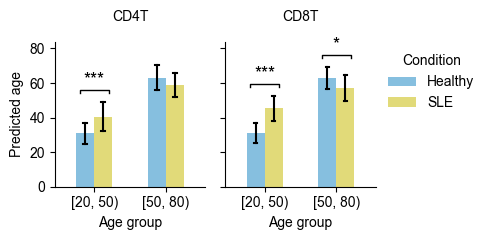

In [63]:
from ciim.src.clock.plots import wrapper_plot_age_acceleration_disease_bins
cell_type = cell_types[0]  # Example cell type, can be changed
# Example usage (make sure n_cell_types, cell_types, and surrogate_names are defined)
wrapper_plot_age_acceleration_disease_bins(obs[obs['cell_type']==cell_type], disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins_cd8t.png', bbox_inches='tight', dpi=300, transparent=True)

aa = wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins.png', bbox_inches='tight', dpi=300, transparent=True)
# aa = wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='Covid_50MHH')

# Perturbation

In [85]:
dataset = 'ibd'  #'CXCL9' # 'op' parsebioscience

In [88]:
obs_pert =  get_all_predictions(cell_types, [dataset])

obs_pert['test_group'] = obs_pert['donor_age'].copy()
obs_pert.head()

,group_col,age,perturbation,sex,IL10,cell_type,condition,donor_id,disease,cell_count,dataset,is_control,donor_age,predicted_age,test_group
38,LPS_CD4T_31,52,LPS,Female,4463.78,CD4T,LPS_CD,31,CD,776,ibd,False,3152,52.278160,3152
39,LPS_CD4T_37,36,LPS,Male,2363.57,CD4T,LPS_CD,37,CD,89,ibd,False,3736,7.369911,3736
40,LPS_CD4T_43,49,LPS,Female,2848.21,CD4T,LPS_CD,43,CD,309,ibd,False,4349,30.515966,4349
41,LPS_CD4T_54,37,LPS,Male,3342.12,CD4T,LPS_CD,54,CD,814,ibd,False,5437,35.167983,5437
43,LPS_CD4T_63,61,LPS,Female,486.98,CD4T,LPS_CD,63,CD,25,ibd,False,6361,42.576780,6361


<Axes: >

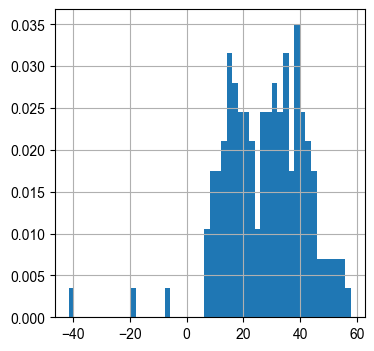

In [96]:
obs_pert['predicted_age'].hist(bins=50, density=True)

In [74]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'Met.',
    # '24 h LPS + metformin + ruxolitinib': 'LPS / Met+Rux', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Met',
    # '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met+Rux',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}
if dataset == 'CXCL9':
    experiments = [
                    # ('24 h RPMI', '24 h rhCXCL9'),
                    ('24 h RPMI', '24 h LPS'),
                    # ('24 h RPMI', '24 h rhIFN-γ'),
                    ('24 h RPMI', '24 h RPMI + metformin'),
                    ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                    # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                    ('24 h LPS', '24 h LPS + metformin'),
                    ('24 h LPS', '24 h LPS + ruxolitinib'),
                    # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                    ]
elif dataset=='op':
    experiments = [('Dimethyl Sulfoxide', treatment) for treatment in obs_pert['condition'].unique() if treatment != 'Dimethyl Sulfoxide']
elif dataset=='parsebioscience':
    ctr = 'PBS'
    experiments = [(ctr, treatment) for treatment in obs_pert['condition'].unique() if treatment != ctr]
else:
    raise ValueError(f"Dataset {dataset} not recognized for drug perturbation experiments.")
n_exp = len(experiments)

In [75]:
if dataset == 'op':
    test_type='mixed_effect'#'mixed_effect'
    p_value_t = 0.0001  # significance threshold
elif dataset == 'CXCL9':
    test_type='paired'
    p_value_t = .05  # significance threshold
elif dataset == 'parsebioscience':
    test_type='mixed_effect'
    p_value_t = 0.0001
else:
    raise ValueError(f'Unknown dataset {dataset}')

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats
from ciim.src.utils.util import test_mixed_effects, test_paired, test_unpaired

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = [] 
slopes = []

for cell_type in obs_pert['cell_type'].unique():
    obs_t = obs_pert[obs_pert['cell_type'] == cell_type].copy()
    
    df_all = obs_t.copy()
    for i, (ctr, treatment) in enumerate(experiments):
        if (df_all['condition']==treatment).sum()<3:
            print(f"Skipping {cell_type} {ctr} vs {treatment} due to insufficient data.")
            continue  # Skip if not enough data
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        if df_sub[df_sub['condition']==treatment]['donor_age'].nunique()<3:
                print(f"Skipping {cell_type} {ctr} vs {treatment} due to insufficient data.")
                continue  # Skip if not enough data        
        if test_type=='paired':
            p_value, slope = test_paired(df_sub, ctr, treatment)
        elif test_type=='unpaired':
            p_value, slope = test_unpaired(df_sub,  ctr, treatment)
        elif test_type=='mixed_effect':
            p_value, slope = test_mixed_effects(dataset, df_sub, ctr, treatment, target_variable='predicted_age')
        if np.isnan(p_value):
            raise ValueError(f"NaN p-value for {cell_type} {ctr} vs {treatment}. Check data quality.")
            
        raw_pvals.append(p_value)
        slopes.append(slope)
        test_labels.append((cell_type, ctr, treatment))

# Apply FDR correction
assert np.isnan(raw_pvals).sum()==0
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

pval_map = {
    (cell_type, ctr, treatment): (pval, slope)
    for (cell_type, ctr, treatment), pval, slope in zip(test_labels, corrected_pvals, slopes)
}

Skipping CD4T Dimethyl Sulfoxide vs Ganetespib (STA-9090) due to insufficient data.
Skipping CD4T Dimethyl Sulfoxide vs Vorinostat due to insufficient data.
Skipping CD4T Dimethyl Sulfoxide vs AT13387 due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs Belinostat due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs Ganetespib (STA-9090) due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs 5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin-6-yl)pyrimidin-2-amine due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs I-BET151 due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs Raloxifene due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs BAY 87-2243 due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs Porcn Inhibitor III due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs Vorinostat due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs Pomalidomide due to insufficient data.
Skipping CD8T Dimethyl Sulfoxide vs N

### Only sig ones

CD4T - Rejuvenating: ['Belinostat', 'Scriptaid', 'LY2090314', 'CHIR-99021', 'Resminostat']
CD4T - Aging: ['RG7112', 'CGM-097', 'Doxorubicin']


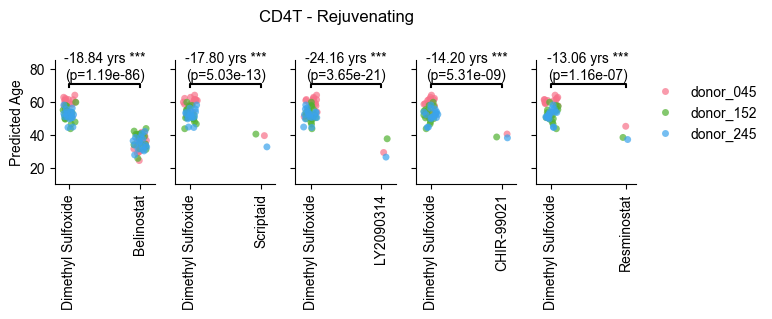

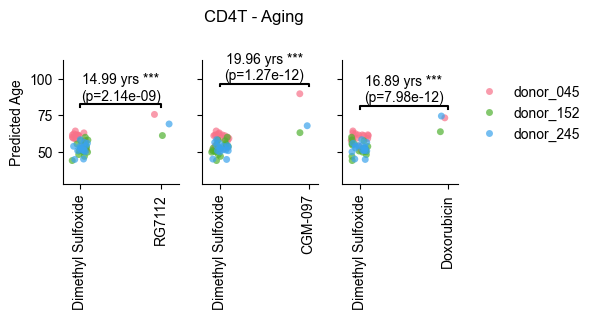

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_experiment(test_type, df_all, ctr, treatment, cell_type, pval_map, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 2.5))
    assert test_type in ['paired', 'unpaired', 'mixed_effect']

    # subset data
    df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()

    # create donor palette (always)
    donors = df_sub['test_group'].unique()
    donor_palette = dict(zip(
        donors,
        sns.color_palette("husl", len(donors))
    ))

    if test_type == "paired":
        # pivot to ensure donors have both conditions
        df_pivot = df_sub.pivot_table(index='test_group', columns='condition', values='predicted_age')
        df_pivot = df_pivot.dropna(subset=[ctr, treatment], how='any')

        df_plot = df_pivot.reset_index().melt(
            id_vars='test_group',
            value_vars=[ctr, treatment],
            var_name='condition',
            value_name='predicted_age'
        )

        sns.lineplot(
            data=df_plot,
            x='condition', y='predicted_age',
            hue='test_group', marker='o', alpha=0.6,
            ax=ax, palette=donor_palette, legend=True
        )
    else:
        # donor-colored scatter dots
        sns.stripplot(
            data=df_sub,
            x='condition', y='predicted_age',
            order=[ctr, treatment],
            dodge=False, jitter=True,
            hue='test_group',
            palette=donor_palette,
            ax=ax, alpha=0.7
        )
        ax.legend_.set_title("Donor")

    # add stats annotation
    pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
    star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

    y_max = df_sub['predicted_age'].max()
    y_bracket = y_max + 7
    h = 2

    ax.plot([0, 0, 1, 1], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
            lw=1.5, c='black')
    ax.text(0.5, y_bracket + 1, f"{slope:.2f} yrs {star}\n(p={pval:.3g})",
            ha='center', va='bottom', fontsize=10)

    ax.set_xlabel("")
    ax.set_ylabel("Predicted Age")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.margins(x=0.1, y=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    return ax
for cell_type in cell_types:
    df_all = obs_pert[obs_pert['cell_type'] == cell_type][['test_group', 'condition', 'predicted_age']].copy()

    # Collect significant experiments
    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < p_value_t
    ]
    
    if not significant_experiments:
        continue

    # Separate by slope direction
    rejuvenating = [(ctr, treatment) for (ctr, treatment) in significant_experiments 
                    if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[1] < 0]
    aging = [(ctr, treatment) for (ctr, treatment) in significant_experiments 
             if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[1] > 0]

    # Now plot each group separately
    for group_name, group_exps in [('Rejuvenating', rejuvenating), ('Aging', aging)]:
        if not group_exps:
            continue

        print(f"{cell_type} - {group_name}: {[tt[1] for tt in group_exps]}")

        # Split into chunks of size 5
        chunk_size = 5
        for i in range(0, len(group_exps), chunk_size):
            chunk = group_exps[i:i+chunk_size]
            fig, axes = plt.subplots(
                1, len(chunk),
                figsize=(1.2 * len(chunk) + 1.5, 1.6),
                sharey=True
            )
            if len(chunk) == 1:
                axes = [axes]

            for ax, (ctr, treatment) in zip(axes, chunk):
                plot_experiment(test_type, df_all, ctr, treatment, cell_type, pval_map, ax=ax)
                try:
                    ax.get_legend().remove()
                except:
                    pass

            fig.suptitle(f'{cell_type} - {group_name}', fontsize=12, weight='bold', y = 1.2)
            plt.legend(loc=[1.1, .3], frameon=False)
            # fig.tight_layout()
            # plt.show()

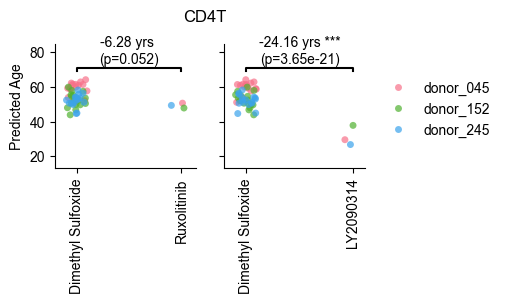

In [77]:
if True:
    for cell_type in ['CD4T']:
        df_all = obs_pert[obs_pert['cell_type'] == cell_type]
        assert df_all.shape[0] > 0 
        if dataset == 'CXCL9':
            plot_experiment(test_type, df_all, ctr='24 h RPMI', treatment='24 h RPMI + ruxolitinib', cell_type=cell_type, pval_map=pval_map)
            plt.legend(loc=(1.2, -.1), frameon=False)
        elif dataset == 'op':
            fig, axes = plt.subplots(1, 2, figsize=(4, 1.6), sharey=True)
            ax = axes[0]
            plot_experiment(test_type, df_all, ctr='Dimethyl Sulfoxide', treatment='Ruxolitinib', cell_type=cell_type, pval_map=pval_map, ax=ax)
            ax.get_legend().remove()
            ax = axes[1]            
            plot_experiment(test_type, df_all, ctr='Dimethyl Sulfoxide', treatment='LY2090314', cell_type=cell_type, pval_map=pval_map, ax=ax)
            plt.legend(loc=(1.1, .2), frameon=False)
        else:
            plot_experiment(test_type, df_all, ctr='PBS', treatment='IL-10', cell_type=cell_type, pval_map=pval_map)
            plt.legend(loc=(1.2, -.1), frameon=False)
        plt.suptitle(f'{cell_type}', y=1.1, weight='bold', fontsize=12)

# IBD

In [ ]:
dataset = 'ibd'
obs_pert =  get_all_predictions(cell_types, [dataset])

obs_pert['test_group'] = obs_pert['donor_age'].copy()
obs_pert.head()

In [116]:
# obs_pert[(obs_pert['condition']=='LPS_CD')&(obs_pert['donor_id']==obs_pert['donor_id'].unique()[4])]
# obs_pert[obs_pert['cell_type']=='CD4T'].copy()

                Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    predicted_age
No. Observations:      72         Method:                REML         
No. Groups:            34         Scale:                 70.7054      
Min. group size:       1          Log-Likelihood:        -266.5045    
Max. group size:       3          Converged:             Yes          
Mean group size:       2.1                                            
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                   17.536    2.846  6.161 0.000 11.957 23.114
disease[T.UC]               -1.267    3.706 -0.342 0.732 -8.531  5.997
perturbation[T.LPS]          1.090    2.166  0.503 0.615 -3.156  5.336
perturbation[T.S. enterica]  3.459    3.489  0.991 0.322 -3.380 10.298
Group Var              

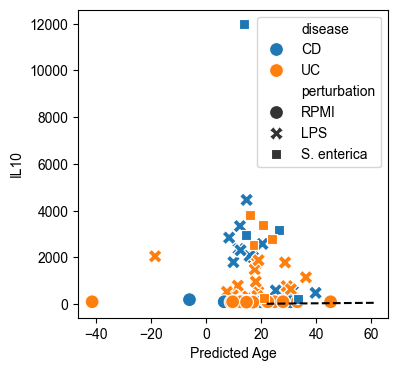

In [117]:
df = obs_pert[obs_pert['cell_type']=='CD8T'].copy()

# Ensure relevant columns are categorical
df['disease'] = df['disease'].astype('category')
df['perturbation'] = df['perturbation'].astype('category')
df['donor_id'] = df['donor_id'].astype('category')

# Set RPMI as the reference for perturbation
df['perturbation'] = df['perturbation'].cat.reorder_categories(
    ['RPMI', 'LPS', 'S. enterica'], ordered=True
)

# Mixed effects model: IL10 ~ disease + perturbation + (1|donor_id)
model = smf.mixedlm(
    "predicted_age ~ disease + perturbation",
    df,
    groups=df["donor_id"]
)
result = model.fit()
print(result.summary())

# Visualize predicted vs actual IL10
sns.scatterplot(
    data=df, x="predicted_age", y="IL10", hue="disease", style="perturbation", s=100
)
plt.plot([df.age.min(), df.age.max()], [df.age.min(), df.age.max()], 'k--')  # identity line
plt.xlabel("Predicted Age")
plt.ylabel("IL10")
plt.show()